# Transformer-Based Backbone Coordinate Refinement

$$\hat{\mathbf{X}} = f_\theta(\tilde{\mathbf{X}},\, h^{\text{ESM2}})$$

Given NeRF-reconstructed backbone coordinates $\tilde{\mathbf{X}} \in \mathbb{R}^{L \times 4 \times 3}$ (from the flow matching model) and ESM-2 per-residue embeddings $h^{\text{ESM2}} \in \mathbb{R}^{L \times 320}$, a transformer encoder refines the coordinates toward the true 3D backbone.

**Key design choices:**
- **Input per residue**: flattened backbone atoms `[N, CA, C, O]` → 12-dim, concatenated with ESM-2 (320-dim)
- **Output**: residual correction δ added to input coordinates (zero-init → starts as identity)
- **Pre-LayerNorm** transformer encoder for training stability
- **Training loss**: MSE on all backbone atoms after Kabsch alignment
- **Limitation**: standard transformers are not SE(3)-equivariant; equivariant architectures (EGNN, SE(3)-Transformer) would be more principled but are out of scope here

**Prerequisites**: Run `combined_conditioned_flow.ipynb` first, then save the trained flow model:
```python
torch.save(flow.state_dict(), 'flow_model.pt')
```

## 1. Imports & Config

In [1]:
import glob
import math
import os
import pickle as pkl
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from Bio import PDB
from Bio.SeqUtils import seq1 as three_to_one
from tqdm import tqdm

from models import ConditionedFlow
from pdb_loading import get_residues_with_positions

AA_LETTERS = 'ACDEFGHIKLMNPQRSTVWY'
device = 'cpu'
torch.manual_seed(42)
np.random.seed(42)
print('Device:', device)

Device: cpu


## 2. Load Existing Resources

In [2]:
# ESM-2 model + tokenizer
esm_model = pkl.load(open('models/esm2_8M.pkl', 'rb'))
tokenizer  = pkl.load(open('models/esm2_8M_tokenizer.pkl', 'rb'))
esm_model.eval()
print('ESM-2 8M loaded')

# Dataset cache (angles + ESM-2 per interior residue)
cache         = pkl.load(open('dataset_cache.pkl', 'rb'))
angles_tensor = cache['angles']     # (N_interior_res, 2) normalised to [-1,1]
esm2_tensor   = cache['esm2']      # (N_interior_res, 320)
all_pdb_ids_r = cache['pdb_ids']   # list[str], one per interior residue
all_aa_chars  = cache['aa_chars']  # list[str]
print(f'Cache: {len(angles_tensor):,} interior residues from {len(set(all_pdb_ids_r))} proteins')

# Flow model (optional — used to generate realistic training noise)
flow = ConditionedFlow(dim=2, embed_dim=320, h=512)
if os.path.exists('flow_model.pt'):
    flow.load_state_dict(torch.load('flow_model.pt', map_location='cpu'))
    flow.eval()
    FLOW_AVAILABLE = True
    print('Flow model loaded from flow_model.pt')
else:
    FLOW_AVAILABLE = False
    print('flow_model.pt not found — will use Gaussian noise augmentation for training.')
    print('Save the trained model in combined_conditioned_flow.ipynb with:')
    print("  torch.save(flow.state_dict(), 'flow_model.pt')")

/Users/sebastian/Desktop/Python/ProteinFolding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ESM-2 8M loaded
Cache: 90,510 interior residues from 200 proteins
Flow model loaded from flow_model.pt


## 3. NeRF Backbone Builder

Reproduced from `combined_conditioned_flow.ipynb` — needed to generate noisy training coordinates.

In [3]:
# Standard backbone geometry
BL = {'n_ca': 1.458, 'ca_c': 1.525, 'c_n': 1.329, 'c_o': 1.229}
BA = {'n_ca_c': 111.2, 'ca_c_n': 116.2, 'c_n_ca': 121.7, 'ca_c_o': 120.8}


def nerf(a, b, c, bond_length, bond_angle_deg, dihedral_deg):
    """Place atom D given anchors A, B, C and bond geometry (dihedral A-B-C-D)."""
    theta = math.radians(bond_angle_deg)
    xi    = math.radians(dihedral_deg)
    bc_hat = (c - b) / np.linalg.norm(c - b)
    n = np.cross(b - a, bc_hat)
    n_norm = np.linalg.norm(n)
    if n_norm < 1e-8:
        perp = np.array([0., 0., 1.]) if abs(bc_hat[2]) < 0.9 else np.array([1., 0., 0.])
        n = np.cross(bc_hat, perp)
        n /= np.linalg.norm(n)
    else:
        n /= n_norm
    m = np.cross(bc_hat, n)
    return c + bond_length * (
        -math.cos(theta) * bc_hat
        + math.sin(theta) * math.cos(xi) * m
        + math.sin(theta) * math.sin(xi) * n
    )


def build_backbone(sequence, phi_psi_deg, omega_deg=180.0):
    """
    NeRF backbone reconstruction.  Returns (L, 4, 3) float64 array,
    atom order [N, CA, C, O], in Angstroms.
    """
    L = len(sequence)
    coords = np.zeros((L, 4, 3), dtype=np.float64)
    ang = math.radians(BA['n_ca_c'])
    coords[0, 0] = [0., 0., 0.]
    coords[0, 1] = [BL['n_ca'], 0., 0.]
    coords[0, 2] = coords[0, 1] + BL['ca_c'] * np.array([
        math.cos(math.pi - ang), math.sin(math.pi - ang), 0.])
    coords[0, 3] = nerf(coords[0,0], coords[0,1], coords[0,2],
                        BL['c_o'], BA['ca_c_o'], phi_psi_deg[0, 1] + 180.)
    for i in range(1, L):
        phi_i, psi_i, psi_p = phi_psi_deg[i,0], phi_psi_deg[i,1], phi_psi_deg[i-1,1]
        np_, cap_, cp_ = coords[i-1, 0], coords[i-1, 1], coords[i-1, 2]
        n_i  = nerf(np_, cap_, cp_,  BL['c_n'],  BA['ca_c_n'], psi_p)
        ca_i = nerf(cap_, cp_, n_i,  BL['n_ca'], BA['c_n_ca'], omega_deg)
        c_i  = nerf(cp_,  n_i, ca_i, BL['ca_c'], BA['n_ca_c'], phi_i)
        o_i  = nerf(n_i,  ca_i, c_i, BL['c_o'],  BA['ca_c_o'], psi_i + 180.)
        coords[i] = [n_i, ca_i, c_i, o_i]
    return coords


print('NeRF utilities ready.')

NeRF utilities ready.


## 4. Extract True Backbone Coordinates from PDB Files

In [4]:
def extract_backbone_coords(pdb_path):
    """
    Extract N, CA, C, O coordinates for all residues using PPBuilder
    (same peptide segmentation used elsewhere in the pipeline).

    Returns
    -------
    sequence : str of length L
    coords   : np.ndarray (L, 4, 3) float32, atom order [N, CA, C, O]
    """
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('s', pdb_path)
    ppb = PDB.PPBuilder()
    seq_list, coord_list = [], []
    for model in structure:
        for chain in model:
            for poly in ppb.build_peptides(chain):
                for residue in poly:
                    try:
                        n  = residue['N'].get_vector().get_array()
                        ca = residue['CA'].get_vector().get_array()
                        c  = residue['C'].get_vector().get_array()
                        o  = residue['O'].get_vector().get_array()
                        aa = three_to_one(residue.resname)
                    except (KeyError, Exception):
                        continue
                    if aa not in AA_LETTERS:
                        continue
                    coord_list.append(np.stack([n, ca, c, o]))
                    seq_list.append(aa)
        break  # first model only
    if not coord_list:
        return None, None
    return ''.join(seq_list), np.stack(coord_list).astype(np.float32)


BACKBONE_CACHE_PATH = 'backbone_coords_cache.pkl'

if os.path.exists(BACKBONE_CACHE_PATH):
    print('Loading cached backbone coordinates...')
    backbone_cache = pkl.load(open(BACKBONE_CACHE_PATH, 'rb'))
else:
    print('Extracting backbone coordinates from PDB files...')
    pdb_files = sorted(glob.glob('PDBs/*.pdb'))
    backbone_cache = {}
    for pdb_path in tqdm(pdb_files):
        pid = os.path.basename(pdb_path).replace('.pdb', '')
        seq, coords = extract_backbone_coords(pdb_path)
        if seq is not None and len(seq) >= 10:
            backbone_cache[pid] = {'seq': seq, 'coords': coords}  # (L,4,3)
    pkl.dump(backbone_cache, open(BACKBONE_CACHE_PATH, 'wb'))
    print(f'Cached {len(backbone_cache)} proteins → {BACKBONE_CACHE_PATH}')

print(f'Backbone cache: {len(backbone_cache)} proteins')

Loading cached backbone coordinates...
Backbone cache: 200 proteins


## 5. Build Full-Protein ESM-2 Cache

The dataset cache only stores embeddings for interior residues. Here we compute
ESM-2 hidden states for every residue in each full protein sequence.

In [5]:
ESM2_FULL_CACHE = 'esm2_full_cache.pkl'

if os.path.exists(ESM2_FULL_CACHE):
    print('Loading full ESM-2 cache...')
    esm2_full_cache = pkl.load(open(ESM2_FULL_CACHE, 'rb'))
else:
    print('Computing full-protein ESM-2 embeddings...')
    esm2_full_cache = {}
    esm_model.eval()
    with torch.no_grad():
        for pid, data in tqdm(backbone_cache.items()):
            seq = data['seq']
            try:
                inputs = tokenizer(seq, return_tensors='pt')
                hidden = esm_model(**inputs).last_hidden_state[0]  # (L+2, 320)
                esm2_full_cache[pid] = hidden[1:len(seq) + 1].numpy()  # (L, 320)
            except Exception as e:
                print(f'  {pid} failed: {e}')
    pkl.dump(esm2_full_cache, open(ESM2_FULL_CACHE, 'wb'))
    print(f'Cached ESM-2 for {len(esm2_full_cache)} proteins → {ESM2_FULL_CACHE}')

print(f'ESM-2 full cache: {len(esm2_full_cache)} proteins')

# Common proteins: present in all three data sources
common_pids = sorted(
    set(backbone_cache) & set(esm2_full_cache) & set(all_pdb_ids_r)
)
print(f'Proteins with backbone + ESM-2 + angles: {len(common_pids)}')

Loading full ESM-2 cache...
ESM-2 full cache: 200 proteins
Proteins with backbone + ESM-2 + angles: 200


## 6. Data Utilities

### Coordinate normalisation & Kabsch alignment

All coordinates are **centred at the Cα centroid** before use.
During training, the noisy NeRF output is **Kabsch-aligned** to the true
structure so the model sees inputs in a consistent frame relative to the target.

> **Note on SO(3) equivariance**: at inference the NeRF frame is arbitrary.
> Centering (but not rotating) is applied, so the model generalises across
> rotations by training on a single aligned frame per protein.
> An SE(3)-equivariant architecture (e.g. EGNN) would be more rigorous.

In [6]:
def center_coords(coords):
    """
    Translate coords (L, 4, 3) so the Cα centroid is at the origin.
    Returns centred coords and the original centroid vector.
    """
    centroid = coords[:, 1].mean(axis=0)       # mean of CA positions
    return coords - centroid[None, None, :], centroid


def kabsch_rotation(P_ca, Q_ca):
    """
    Compute rotation matrix R that minimises RMSD between P_ca and Q_ca.
    Both inputs (L, 3), already centred.
    Returns R (3, 3) such that (P @ R.T) ≈ Q.
    """
    H = P_ca.T @ Q_ca
    U, _, Vt = np.linalg.svd(H)
    d = np.linalg.det(Vt.T @ U.T)             # handle reflections
    R = Vt.T @ np.diag([1., 1., d]) @ U.T
    return R


def kabsch_align(noisy_coords, true_coords):
    """
    Rigid-body align noisy_coords to true_coords using Cα Kabsch.
    Both (L, 4, 3), already centred.  Returns aligned noisy (L, 4, 3).
    """
    R = kabsch_rotation(noisy_coords[:, 1], true_coords[:, 1])
    return (noisy_coords.reshape(-1, 3) @ R.T).reshape(noisy_coords.shape)


def ca_rmsd(pred, true):
    """
    Cα RMSD in Å.  Accepts (L, 4, 3) or (L, 3) arrays.
    Kabsch-aligns pred to true before computing RMSD.
    """
    pc = pred[:, 1] if pred.ndim == 3 else pred
    tc = true[:, 1] if true.ndim == 3 else true
    # align
    pc_c = pc - pc.mean(0)
    tc_c = tc - tc.mean(0)
    R = kabsch_rotation(pc_c, tc_c)
    pc_aligned = pc_c @ R.T
    return float(np.sqrt(((pc_aligned - tc_c) ** 2).sum(-1).mean()))


print('Data utilities ready.')

Data utilities ready.


## 7. Training Pair Builder

For each protein, generate a `(noisy_coords, true_coords, esm2)` triple:

| Source | How |  
|--------|-----|
| **true_coords** | Extracted directly from PDB; centred at Cα centroid |
| **noisy_coords** | True φ/ψ + Gaussian noise → NeRF → centred → Kabsch-aligned to true |
| **esm2** | Full-protein ESM-2 hidden states |

If `flow_model.pt` is available, the actual flow model output is used as
noisy coordinates for one of the `n_flow` repeats per protein.

In [7]:
def _get_protein_phi_psi(pid, L):
    """
    Build (L, 2) phi/psi array in degrees for a protein.
    Interior residues come from the dataset cache (true angles).
    Terminal residues default to (-60, -40) — canonical helix-like geometry.
    """
    mask      = [p == pid for p in all_pdb_ids_r]
    int_ph_ps = angles_tensor[torch.tensor(mask)].numpy() * 180.0   # (n_int, 2)
    phi_psi   = np.full((L, 2), [-60., -40.], dtype=np.float32)
    n = min(len(int_ph_ps), L - 2)
    if n > 0:
        phi_psi[1:1 + n] = int_ph_ps[:n]
    return phi_psi


@torch.no_grad()
def build_training_pair(pid, noise_std=25.0, use_flow=False):
    """
    Build a (noisy_coords, true_coords, esm2_emb) training triple.

    noisy_coords : torch.Tensor (L, 12)  — flattened [N,CA,C,O]×xyz, Kabsch-aligned, centred
    true_coords  : torch.Tensor (L, 12)  — from PDB, centred
    esm2_emb     : torch.Tensor (L, 320)
    """
    if pid not in backbone_cache or pid not in esm2_full_cache:
        return None

    data     = backbone_cache[pid]
    seq      = data['seq']
    L        = len(seq)
    true_raw = data['coords'].astype(np.float64)   # (L, 4, 3)
    esm2_emb = esm2_full_cache[pid]                # (L, 320)

    if len(true_raw) != L or len(esm2_emb) != L or L < 5:
        return None

    # ── True coordinates: centre ─────────────────────────────────────────────
    true_c, _ = center_coords(true_raw)

    # ── Noisy coordinates ────────────────────────────────────────────────────
    if use_flow and FLOW_AVAILABLE:
        # Use the actual trained flow model to generate angles
        emb = torch.tensor(esm2_emb, dtype=torch.float32)
        x   = torch.randn(L, 2)
        ts  = torch.linspace(0., 1., 21)
        for i in range(20):
            t_s = ts[i].view(1, 1).expand(L, 1)
            dt  = (ts[i + 1] - ts[i]).float()
            v_s = flow(t_s, x, emb)
            v_m = flow(t_s + dt / 2, x + v_s * dt / 2, emb)
            x   = x + dt * v_m
        phi_psi = x.numpy() * 180.0                   # (L, 2)
    else:
        # Gaussian noise on true angles (simulates flow model residuals)
        phi_psi = _get_protein_phi_psi(pid, L)
        phi_psi = phi_psi + np.random.randn(L, 2).astype(np.float32) * noise_std

    noisy_raw  = build_backbone(seq, phi_psi)         # (L, 4, 3)
    noisy_c, _ = center_coords(noisy_raw)

    # ── Kabsch-align noisy to true (correct arbitrary NeRF orientation) ──────
    noisy_aligned = kabsch_align(noisy_c, true_c)

    return (
        torch.tensor(noisy_aligned.reshape(L, 12), dtype=torch.float32),
        torch.tensor(true_c.reshape(L, 12),         dtype=torch.float32),
        torch.tensor(esm2_emb,                       dtype=torch.float32),
    )


# Quick smoke-test
test_build_pid = common_pids[0]
pair = build_training_pair(test_build_pid)
if pair is not None:
    nc, tc, emb = pair
    print(f'Test pair for {test_build_pid}:')
    print(f'  noisy_coords : {nc.shape}')
    print(f'  true_coords  : {tc.shape}')
    print(f'  esm2         : {emb.shape}')
    before = ca_rmsd(nc.numpy().reshape(-1, 4, 3), tc.numpy().reshape(-1, 4, 3))
    print(f'  Cα RMSD (pre-refinement): {before:.3f} Å')
else:
    print(f'build_training_pair returned None for {test_build_pid}')

Test pair for 101M:
  noisy_coords : torch.Size([154, 12])
  true_coords  : torch.Size([154, 12])
  esm2         : torch.Size([154, 320])
  Cα RMSD (pre-refinement): 20.226 Å


## 8. CoordRefiner Model

```
Input  (L, 332) = cat[noisy_coords (L,12), ESM-2 (L,320)]
   ↓  Linear → d_model
   ↓  + Learned positional embedding
   ↓  TransformerEncoder  (pre-LN, 4 layers, 8 heads)
   ↓  Linear → (L, 12)  [residual δ]
Output = noisy_coords + δ          (L, 12)
```

The output projection is zero-initialised, so the model starts as an identity map.

In [8]:
from models import CoordRefiner

refiner = CoordRefiner(
    coord_dim=12, esm2_dim=320, d_model=256,
    nhead=8, num_layers=4, ffn_dim=1024, dropout=0.1,
)
n_params = sum(p.numel() for p in refiner.parameters())
print(f'CoordRefiner — {n_params:,} parameters')
print(f'Max sequence length (pos embedding): {refiner.pos_emb.num_embeddings}')

CoordRefiner — 3,771,660 parameters
Max sequence length (pos embedding): 2048


## 9. Train / Test Split

In [9]:
random.seed(42)
n_test     = max(1, len(common_pids) // 10)
test_pids  = set(random.sample(common_pids, n_test))
train_pids = [p for p in common_pids if p not in test_pids]

print(f'Train proteins : {len(train_pids)}')
print(f'Test  proteins : {len(test_pids)}')

Train proteins : 180
Test  proteins : 20


## 10. Training

One protein per forward pass (variable-length sequences — no padding needed).

**Loss**: MSE on all backbone atoms (N, CA, C, O) in the Kabsch-aligned frame.
Gradient clipping (norm 1.0) stabilises training on proteins with very different lengths.

In [10]:
EPOCHS      = 30
LR          = 3e-4
NOISE_STD   = 25.0    # degrees — simulates flow model angle residuals
PRINT_EVERY = 5
MAX_SEQ_LEN = refiner.pos_emb.num_embeddings   # skip proteins longer than pos-emb table

optimizer = torch.optim.Adam(refiner.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS * len(train_pids)
)

loss_history = []

for epoch in range(EPOCHS):
    refiner.train()
    epoch_losses = []
    pids_shuffled = random.sample(train_pids, len(train_pids))

    for pid in pids_shuffled:
        use_flow = FLOW_AVAILABLE and (hash(pid) % 5 == 0)
        pair = build_training_pair(pid, noise_std=NOISE_STD, use_flow=use_flow)
        if pair is None:
            continue
        noisy_coords, true_coords, esm2_emb = pair

        # Guard: skip sequences longer than the positional-embedding table.
        # (CoordRefiner.forward clamps indices as a fallback, but training on
        #  sequences where many positions share one embedding is not useful.)
        if noisy_coords.shape[0] > MAX_SEQ_LEN:
            continue

        optimizer.zero_grad()
        refined = refiner(noisy_coords, esm2_emb)
        loss    = F.mse_loss(refined, true_coords)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(refiner.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')
    loss_history.extend(epoch_losses)
    if (epoch + 1) % PRINT_EVERY == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | loss {mean_loss:.5f} | lr {lr_now:.2e}')

print('Training complete.')
torch.save(refiner.state_dict(), 'coord_refiner.pt')
print('Saved → coord_refiner.pt')

Epoch   5/30 | loss 137.86346 | lr 2.80e-04
Epoch  10/30 | loss 132.89099 | lr 2.27e-04
Epoch  15/30 | loss 129.86990 | lr 1.53e-04
Epoch  20/30 | loss 128.23329 | lr 7.80e-05
Epoch  25/30 | loss 126.97333 | lr 2.23e-05
Epoch  30/30 | loss 128.49553 | lr 9.14e-08
Training complete.
Saved → coord_refiner.pt


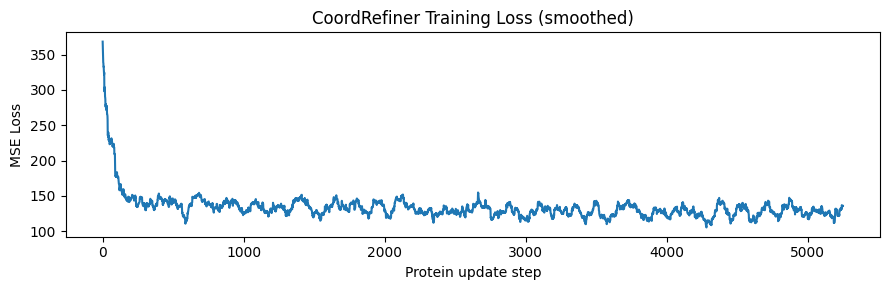

In [11]:
w = max(1, len(train_pids) // 2)   # smooth over ~half an epoch
smoothed = np.convolve(loss_history, np.ones(w) / w, mode='valid')

plt.figure(figsize=(9, 3))
plt.plot(smoothed)
plt.xlabel('Protein update step')
plt.ylabel('MSE Loss')
plt.title('CoordRefiner Training Loss (smoothed)')
plt.tight_layout()
plt.show()

## 11. Evaluation — Cα RMSD Before vs After Refinement

For each test protein:
1. Generate noisy NeRF coordinates (Gaussian noise on true angles)
2. Compute Cα RMSD *before* refinement (noisy vs true)
3. Compute Cα RMSD *after* refinement (model output vs true)

Both RMSD values are computed using Kabsch alignment so global translation/rotation
does not inflate the metric.

In [16]:
refiner.eval()

before_rmsds, after_rmsds, lengths = [], [], []

with torch.no_grad():
    for pid in tqdm(sorted(test_pids)):
        pair = build_training_pair(pid, noise_std=NOISE_STD, use_flow=False)
        if pair is None:
            continue
        noisy_coords, true_coords, esm2_emb = pair
        refined = refiner(noisy_coords, esm2_emb)

        nc = noisy_coords.numpy().reshape(-1, 4, 3)
        tc = true_coords.numpy().reshape(-1, 4, 3)
        rc = refined.numpy().reshape(-1, 4, 3)

        before_rmsds.append(ca_rmsd(nc, tc))
        after_rmsds.append(ca_rmsd(rc, tc))
        lengths.append(len(nc))

before_arr = np.array(before_rmsds)
after_arr  = np.array(after_rmsds)
improvement = before_arr - after_arr

print(f'Test proteins evaluated : {len(before_arr)}')
print()
print(f'Cα RMSD BEFORE refinement : {before_arr.mean():.3f} ± {before_arr.std():.3f} Å')
print(f'Cα RMSD AFTER  refinement : {after_arr.mean():.3f} ± {after_arr.std():.3f} Å')
print(f'Mean improvement          : {improvement.mean():.3f} Å  '
      f'(positive = better; {(improvement > 0).mean()*100:.0f}% of proteins improved)')

100%|██████████| 20/20 [00:02<00:00,  7.86it/s]

Test proteins evaluated : 20

Cα RMSD BEFORE refinement : 35.126 ± 16.918 Å
Cα RMSD AFTER  refinement : 17.668 ± 8.022 Å
Mean improvement          : 17.458 Å  (positive = better; 100% of proteins improved)


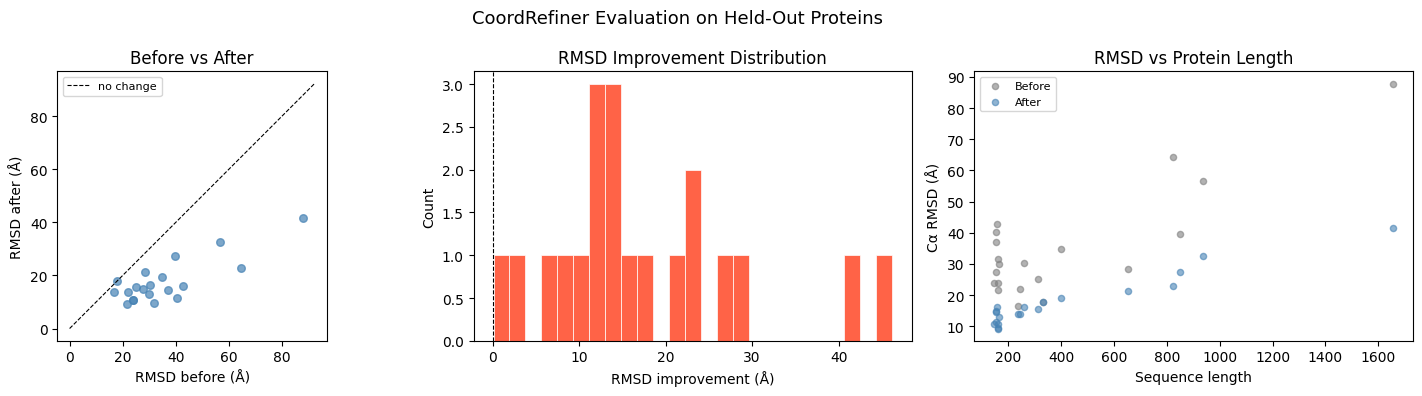

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('CoordRefiner Evaluation on Held-Out Proteins', fontsize=13)

# Scatter: before vs after
axes[0].scatter(before_arr, after_arr, s=30, alpha=0.7, color='steelblue')
max_rmsd = max(before_arr.max(), after_arr.max()) * 1.05
axes[0].plot([0, max_rmsd], [0, max_rmsd], 'k--', lw=0.8, label='no change')
axes[0].set_xlabel('RMSD before (Å)')
axes[0].set_ylabel('RMSD after (Å)')
axes[0].set_title('Before vs After')
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')

# Histogram of improvement
axes[1].hist(improvement, bins=25, color='tomato', edgecolor='white', lw=0.5)
axes[1].axvline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('RMSD improvement (Å)')
axes[1].set_ylabel('Count')
axes[1].set_title('RMSD Improvement Distribution')

# RMSD vs sequence length
axes[2].scatter(lengths, before_arr, s=20, alpha=0.6, color='grey',     label='Before')
axes[2].scatter(lengths, after_arr,  s=20, alpha=0.6, color='steelblue', label='After')
axes[2].set_xlabel('Sequence length')
axes[2].set_ylabel('Cα RMSD (Å)')
axes[2].set_title('RMSD vs Protein Length')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 12. Full Inference Pipeline

```
sequence  ──→  ESM-2  ──→  h_i (320)
                                   ↘
                   flow matching ──→  φ_i, ψ_i
                                           ↓
                                         NeRF
                                           ↓
                                  noisy_coords (L, 4, 3)
                                           ↓
                                   CoordRefiner
                                           ↓
                                  refined_coords (L, 4, 3)
                                           ↓
                                         PDB
```

In [14]:
ONE_TO_THREE = {
    'A':'ALA','C':'CYS','D':'ASP','E':'GLU','F':'PHE',
    'G':'GLY','H':'HIS','I':'ILE','K':'LYS','L':'LEU',
    'M':'MET','N':'ASN','P':'PRO','Q':'GLN','R':'ARG',
    'S':'SER','T':'THR','V':'VAL','W':'TRP','Y':'TYR',
}
BACKBONE_ATOM_NAMES = ['N', 'CA', 'C', 'O']


def write_pdb(filepath, sequence, coords, chain_id='A', remark='CoordRefiner output'):
    """Write backbone (N, CA, C, O) coordinates to a PDB file."""
    lines  = [f'REMARK  {remark}\n']
    serial = 1
    for res_idx, (aa, res_coords) in enumerate(zip(sequence, coords)):
        res_num  = res_idx + 1
        res_name = ONE_TO_THREE.get(aa, 'UNK')
        for atom_name, (x, y, z) in zip(BACKBONE_ATOM_NAMES, res_coords):
            name_field = f' {atom_name:<3s}' if len(atom_name) < 4 else atom_name
            lines.append(
                f'ATOM  {serial:5d} {name_field:<4s}{res_name:>3s} {chain_id}'
                f'{res_num:4d}    {x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00'
                f'          {atom_name[0]:>2s}\n'
            )
            serial += 1
    lines.append('END\n')
    with open(filepath, 'w') as fh:
        fh.writelines(lines)
    print(f'Wrote {serial-1} atoms ({len(sequence)} residues) → {filepath}')


@torch.no_grad()
def generate_and_refine(
    sequence,
    flow_model,
    refiner_model,
    esm_model,
    tokenizer,
    flow_steps=50,
    output_pdb=None,
    device='cpu',
):
    """
    End-to-end pipeline: sequence → refined backbone PDB.

    Parameters
    ----------
    sequence      : str  amino acid sequence
    flow_model    : trained ConditionedFlow
    refiner_model : trained CoordRefiner
    esm_model     : ESM-2 model
    tokenizer     : ESM-2 tokenizer
    flow_steps    : int  ODE integration steps for flow model
    output_pdb    : str or None — if given, writes PDB to this path
    device        : 'cpu' or 'cuda'

    Returns
    -------
    nerf_coords     : np.ndarray (L, 4, 3)  raw NeRF output (centred)
    refined_coords  : np.ndarray (L, 4, 3)  after transformer refinement
    phi_psi_deg     : np.ndarray (L, 2)     generated torsion angles
    """
    L = len(sequence)
    flow_model.eval()
    refiner_model.eval()
    esm_model.eval()

    # ── Step 1: ESM-2 per-residue embeddings ─────────────────────────────────
    inputs   = tokenizer(sequence, return_tensors='pt').to(device)
    hidden   = esm_model(**inputs).last_hidden_state[0]    # (L+2, 320)
    esm2_emb = hidden[1:L + 1].to(device)                 # (L, 320)

    # ── Step 2: Flow matching → φ/ψ per residue ──────────────────────────────
    x  = torch.randn(L, 2, device=device)
    ts = torch.linspace(0., 1., flow_steps + 1, device=device)
    for i in range(flow_steps):
        t_s = ts[i].view(1, 1).expand(L, 1)
        dt  = (ts[i + 1] - ts[i]).float()
        v_s = flow_model(t_s, x, esm2_emb)
        v_m = flow_model(t_s + dt/2, x + v_s*dt/2, esm2_emb)
        x   = x + dt * v_m
    phi_psi_deg = x.cpu().numpy() * 180.0                  # (L, 2)

    # ── Step 3: NeRF reconstruction ───────────────────────────────────────────
    nerf_raw           = build_backbone(sequence, phi_psi_deg)   # (L, 4, 3)
    nerf_centred, _    = center_coords(nerf_raw)

    # ── Step 4: Transformer refinement ───────────────────────────────────────
    noisy_t  = torch.tensor(nerf_centred.reshape(L, 12), dtype=torch.float32)
    refined_t = refiner_model(noisy_t, esm2_emb.cpu())
    refined_coords = refined_t.numpy().reshape(L, 4, 3)

    # ── Step 5: Optional PDB export ──────────────────────────────────────────
    if output_pdb is not None:
        write_pdb(output_pdb, sequence, refined_coords)

    return nerf_centred, refined_coords, phi_psi_deg


print('generate_and_refine() pipeline ready.')

generate_and_refine() pipeline ready.


## 13. Example — Generate & Refine a Held-Out Test Protein

Protein  : 104M
Length   : 153 residues
Sequence : VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASED...
Wrote 612 atoms (153 residues) → 104M_refined.pdb

Cα RMSD before refinement : 45.530 Å
Cα RMSD after  refinement : 12.577 Å
Improvement               : +32.953 Å


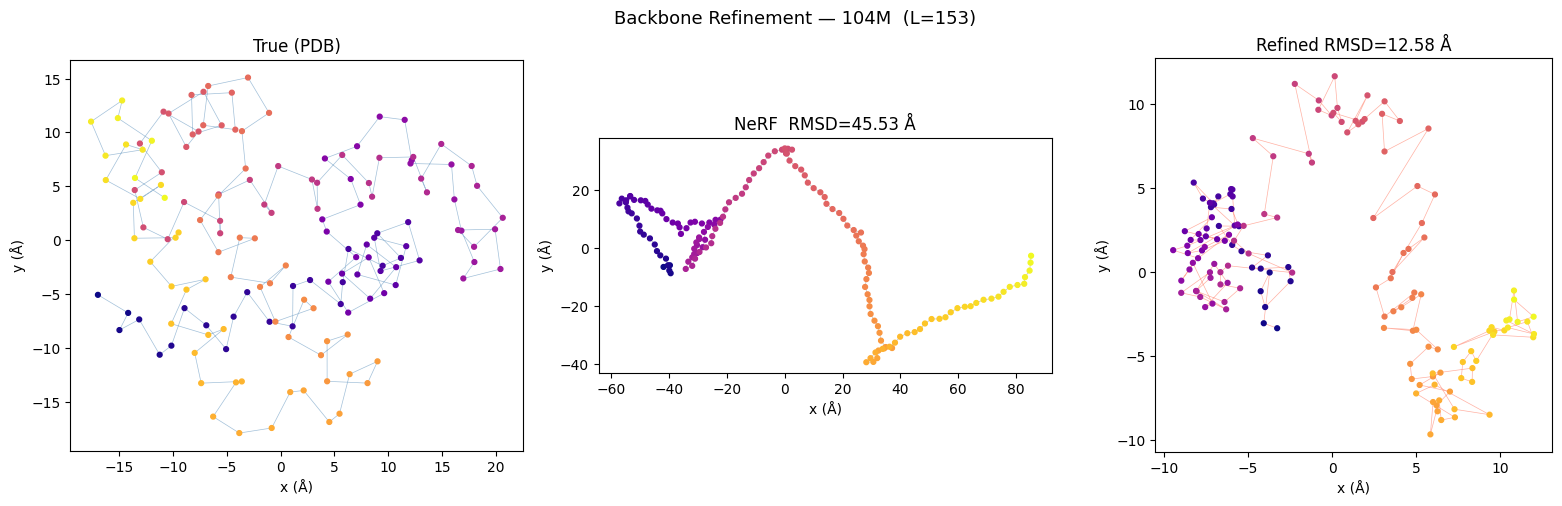


Refined PDB saved → 104M_refined.pdb
Open in PyMOL / ChimeraX to view the 3D structure.


In [15]:
example_pid = sorted(test_pids)[0]
example_seq = backbone_cache[example_pid]['seq']
true_coords = backbone_cache[example_pid]['coords']     # (L, 4, 3)
true_c, _   = center_coords(true_coords)

print(f'Protein  : {example_pid}')
print(f'Length   : {len(example_seq)} residues')
print(f'Sequence : {example_seq[:60]}...' if len(example_seq) > 60 else f'Sequence : {example_seq}')

if FLOW_AVAILABLE:
    nerf_coords, refined_coords, angles = generate_and_refine(
        example_seq, flow, refiner, esm_model, tokenizer,
        output_pdb=f'{example_pid}_refined.pdb',
    )
else:
    # Fallback: use Gaussian-noised angles for demo
    pair = build_training_pair(example_pid, noise_std=NOISE_STD, use_flow=False)
    noisy_t, _, esm2_t = pair
    with torch.no_grad():
        refined_t = refiner(noisy_t, esm2_t)
    nerf_coords    = noisy_t.numpy().reshape(-1, 4, 3)
    refined_coords = refined_t.numpy().reshape(-1, 4, 3)
    angles         = np.zeros((len(example_seq), 2))
    write_pdb(f'{example_pid}_refined.pdb', example_seq, refined_coords)

rmsd_before = ca_rmsd(nerf_coords,    true_c)
rmsd_after  = ca_rmsd(refined_coords, true_c)

print(f'\nCα RMSD before refinement : {rmsd_before:.3f} Å')
print(f'Cα RMSD after  refinement : {rmsd_after:.3f} Å')
print(f'Improvement               : {rmsd_before - rmsd_after:+.3f} Å')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Backbone Refinement — {example_pid}  (L={len(example_seq)})', fontsize=13)

def plot_ca_trace(ax, coords, label, color, alpha=1.0):
    ca = coords[:, 1]
    sc = ax.scatter(ca[:, 0], ca[:, 1], c=np.arange(len(ca)), cmap='plasma',
                    s=12, alpha=alpha, zorder=3)
    ax.plot(ca[:, 0], ca[:, 1], lw=0.5, color=color, alpha=0.5 * alpha)
    ax.set_title(label)
    ax.set_xlabel('x (Å)'); ax.set_ylabel('y (Å)')
    ax.set_aspect('equal')
    return sc

plot_ca_trace(axes[0], true_c,       f'True (PDB)',                     'steelblue')
plot_ca_trace(axes[1], nerf_coords,  f'NeRF  RMSD={rmsd_before:.2f} Å', 'grey')
plot_ca_trace(axes[2], refined_coords, f'Refined RMSD={rmsd_after:.2f} Å', 'tomato')

plt.tight_layout()
plt.show()

print(f'\nRefined PDB saved → {example_pid}_refined.pdb')
print('Open in PyMOL / ChimeraX to view the 3D structure.')

In [22]:
import pickle
with open('protein_codes.txt', 'r') as fh:
    eval_data = list(fh)

In [30]:
len(eval_data[0].split(' '))

96010